# Genetic Algorithm – Vermeer's *Girl with a Pearl Earring*

Approximate a target painting using **100 semi-transparent triangles** evolved by a Genetic Algorithm.

### Representation
Each individual is a flat list of **1 000 floats** (all in `[0, 1]`):  
100 triangles × 10 genes each → `[x1, y1, x2, y2, x3, y3, r, g, b, α]`

### Fitness
**Root Mean Squared Error (RMSE)** between the rendered image and the original — we **minimise** it.

### GA operators
| Component | Operator |
|-----------|----------|
| Selection | Tournament (size 3) |
| Crossover | One Point Crossover |
| Mutation  | Gaussian Mutation |

## 1. Setup

In [37]:
import numpy as np
from typing import Callable
from PIL import Image
import os
import random
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from time import time

genes_per_triangle = 10

Import from our library

* solution, triangle_solution and the data
* Selection: tournament
* Mutation: gaussian
* Crossover: one_point_crossover

In [38]:
from library.problem.solution import Solution
from library.problem.triangle_solution import TriangleSolution

from library.problem.fitness_sharing import apply_fitness_sharing
from library.algorithms.geneticalgorithms.selection import tournament_selection, rank_selection
from library.algorithms.geneticalgorithms.crossover import one_point_crossover, two_point_crossover
from library.algorithms.geneticalgorithms.mutation import gaussian_mutation, uniform_mutation

## 2. Load and display the target image

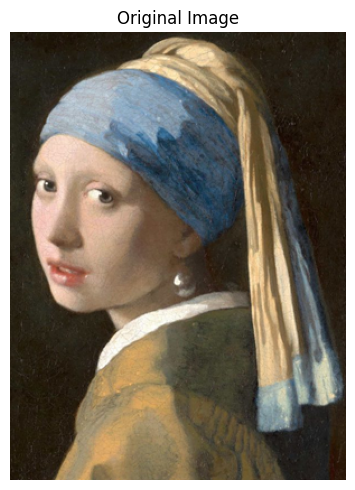

In [39]:
image_path = os.path.join('library', 'problem', 'data', 'girl_pearl_earing.png')

original_image = Image.open(image_path).convert('RGB')
original_image_array = np.array(original_image, dtype=np.uint8)

fig, ax = plt.subplots(figsize=(4, 5))
ax.imshow(original_image)
ax.axis('off')
ax.set_title('Original Image')
plt.tight_layout()
plt.show()

## 3. The First Genetic Algorithm

### Elitism

In [40]:
# We're going to create a function to get the best individual, which has the lowest fitness value so that we can apply elitism

def get_best_individual(population: list, minimization: bool = True):
    """
    Returns the best individual from the population based on fitness values.
    If minimization is True, it returns the individual with the lowest fitness value; otherwise, it returns the individual with the highest fitness value.

    Args:
        population (list): The population of individuals
        minimization (bool, optional): If True (the default), considers that lower values of fitness are better; otherwise, the opposite.
    """
    
    fitness_list = [ind.fitness() for ind in population]
    if minimization:
        return population[fitness_list.index(min(fitness_list)) ]
    else:
        return population[fitness_list.index(max(fitness_list)) ]

### Diversity

In [41]:
def compute_diversity(population):
    """
    Mean pairwise Euclidean distance between individuals, computed on per-gene-normalised genomes so that vertex, colour and alpha genes all contribute on a common [0, 1] scale.

    Each gene is divided by its natural range before the distance is computed:
        • x  → img_width
        • y  → img_height
        • r, g, b → 255
        • α  → 1   (already in [0, 1])

    This makes the diversity value independent of image size and of the relative magnitudes of the three gene families, so values are comparable across runs and across images.

    Parameters:
        population (list[TriangleSolution]): Current population. All individuals are assumed to have the same genome length and the same image dimensions.

    Returns:
        float: Mean Euclidean distance over all unordered pairs of normalised genomes.
    """
    W, H = population[0].img_width, population[0].img_height
    D = len(population[0].repr)

    # Per-gene divisor for one triangle, tiled across the whole genome.
    block_scale = np.array([W, H, W, H, W, H, 255.0, 255.0, 255.0, 1.0])
    scale = np.tile(block_scale, D // genes_per_triangle)

    reprs = np.asarray([ind.repr for ind in population], dtype=np.float64) / scale
    return float(pdist(reprs, metric='euclidean').mean())

### Genetic Algorithm

In [42]:
# Now let's create the genetic algorithm function
def genetic_algorithm(
    initial_population: list,
    max_generations: int,
    selection_algorithm: Callable,
    xo_method: Callable,
    mut_method: Callable,
    minimization: bool = True,
    xo_prob: float = 0.9,
    mut_prob: float = 0.1,
    elitism: bool = True,
    fitness_sharing: bool = False,
    sigma_share: float = 3.0,
    verbose: bool = False
):
    """
    Executes a genetic algorithm to optimize a population of individuals

    Args:
        initial_population (list): The starting population of individuals.
        max_generations (int): The maximum number of generations to evolve.
        selection_algorithm (Callable): Function used for selecting individuals.
        xo_method (Callable): Function for crossover between two individuals.
        mut_method (Callable): Function used for mutating an individual.
        minimization (bool, optional): If True, minimizes the fitness function; if False, maximizes it. Defaults to True.
        xo_prob (float, optional): Probability of applying crossover. Defaults to 0.9.
        mut_prob (float, optional): Probability of applying mutation. Defaults to 0.1.
        elitism (bool, optional): If True, preserves the best individuals across generations. Defaults to True.
        fitness_sharing (bool, optional): If True, applies fitness sharing to promote diversity. Defaults to False.
        sigma_share (float, optional): The sharing radius for fitness sharing. Defaults to 3.0.
        verbose (bool, optional): If True, prints progress information. Defaults to False.
    
    Returns:
        Solution: The best solution found after evolving the population.
        list[float]: The fitness of the best individual over the generations.
    """
    
    starttime = time()
    best_fitness_over_gens = []
    best_individuals_over_gens = []
    diversity_over_gens = []
    
    # 1. Initialize the population
    
    population = initial_population
    
    # 2. Repeat until stopping criterion is met (max_generations)
    for gen in range(1, max_generations + 1):
        gen_starttime = time()
        
        # Print generation number even if verbose is False.
        print(f'----- Generation {gen}/{max_generations}, duration: {gen_starttime - starttime:.2f} -----')
        
        if fitness_sharing:
            apply_fitness_sharing(population, sigma_share)
            select_key = lambda ind: ind.shared_fitness
        else:
            select_key = None  # selection uses raw fitness
        
        # 2.1. Create an empty list for the new population
        new_population = []
        
        # 2.2. If elitism is enabled, add the best individual from the current population to the new population
        if elitism:
            
            new_population.append(get_best_individual(population, minimization))
            
        # 2.3. While the new population is not full, repeat:
        while len(new_population) < len(population):
            
            # 2.3.1. Choose 2 individuals from current population using a selection algorithm
            first_ind  = selection_algorithm(population, minimization, key=select_key)
            second_ind = selection_algorithm(population, minimization, key=select_key)
            
            # 2.3.2. Choose between crossover and replication.
            # 2.3.3. Apply the operator to generate the offspring.
            offspring1, offspring2 = xo_method(first_ind, second_ind, xo_prob, verbose)
            
            # 2.3.4. Apply mutation to the offspring.
            first_new_ind = mut_method(offspring1, mut_prob)
            
            # 2.3.5. Add the new individual to the new population.
            new_population.append(first_new_ind)
            
            # Check if we can add the second offspring or if we have already reached the population size limit
            if len(new_population) < len(population):
                second_new_ind = mut_method(offspring2, mut_prob)
                new_population.append(second_new_ind)
                
                if verbose:
                    print(f'Mutated individuals added: {first_new_ind} and {second_new_ind}')
            else:
                if verbose:
                    print(f'Mutated individual added: {first_new_ind}. Population limit reached, so second offspring not added.')
                    
        # 2.4. Replace the current population with the new population
        population = new_population
        
        best_ind = get_best_individual(population, minimization)
        best_fitness_over_gens.append(best_ind.fitness())
        best_individuals_over_gens.append(best_ind)
        diversity_over_gens.append(compute_diversity(population))
        
        if verbose:
            print(f'Final best individual in generation: {get_best_individual(population, minimization).fitness()}')
            
    # 3. Return the best individual from the population and the best individual's fitness at each generation as well as the best individual at each generation
    return best_ind, best_fitness_over_gens, best_individuals_over_gens, diversity_over_gens

Now let's try running with and without elitism. To compare both approaches

In [43]:
# Create the initial population of solutions
def create_population(size=100):
    population = []
    for _ in range(size):
        population.append(TriangleSolution(
            target_array=original_image_array,
            img_width=original_image.width,
            img_height=original_image.height,
            n_triangles=100,
        ))
    return population

# Run the genetic algorithm without elitism
random.seed(1)
GA_NoElite = genetic_algorithm(
    initial_population=create_population(),
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=one_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=False,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False
)


# Same code, now with elitism
random.seed(1)
GA_Elite = genetic_algorithm(
    initial_population=create_population(),
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=one_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False
)

print(f'---------- Final Results ----------')
print(f'Best solution without elitism has fitness: {GA_NoElite[0].fitness()}')
print(f'Best solution with elitism has fitness: {GA_Elite[0].fitness()}')

----- Generation 1/300, duration: 0.00 -----
----- Generation 2/300, duration: 1.29 -----
----- Generation 3/300, duration: 2.00 -----
----- Generation 4/300, duration: 2.66 -----
----- Generation 5/300, duration: 3.33 -----
----- Generation 6/300, duration: 3.99 -----
----- Generation 7/300, duration: 4.66 -----
----- Generation 8/300, duration: 5.35 -----
----- Generation 9/300, duration: 6.02 -----
----- Generation 10/300, duration: 6.69 -----
----- Generation 11/300, duration: 7.37 -----
----- Generation 12/300, duration: 8.05 -----
----- Generation 13/300, duration: 8.72 -----
----- Generation 14/300, duration: 9.40 -----
----- Generation 15/300, duration: 10.08 -----
----- Generation 16/300, duration: 10.76 -----
----- Generation 17/300, duration: 11.46 -----
----- Generation 18/300, duration: 12.14 -----
----- Generation 19/300, duration: 12.82 -----
----- Generation 20/300, duration: 13.50 -----
----- Generation 21/300, duration: 14.19 -----
----- Generation 22/300, duration: 1

### Visualization of Fitness and Diversity throught generations

#### Fitness Evolution

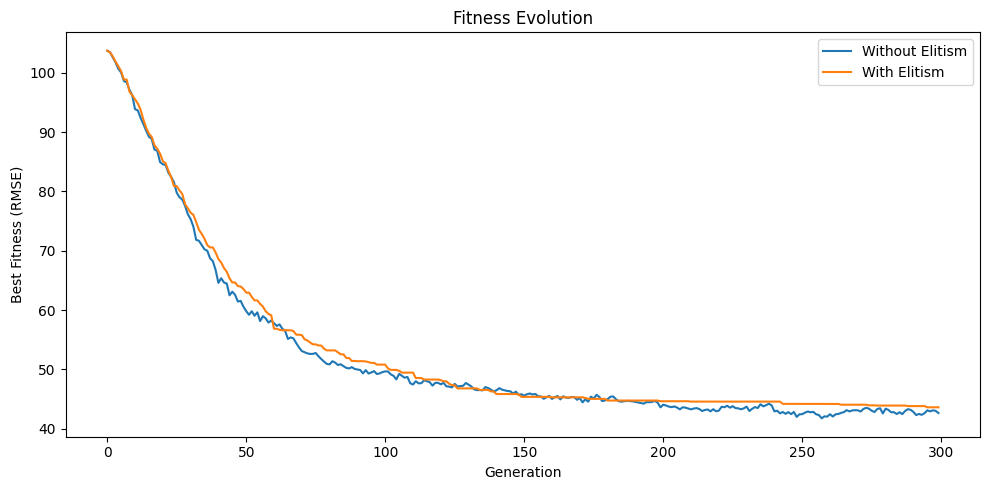

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(GA_NoElite[1], label='Without Elitism')
plt.plot(GA_Elite[1], label='With Elitism')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (RMSE)')
plt.title('Fitness Evolution')
plt.legend()
plt.tight_layout()
plt.savefig('output/fitness_evolution.png', bbox_inches='tight')
plt.show()

#### Diversity Evolution

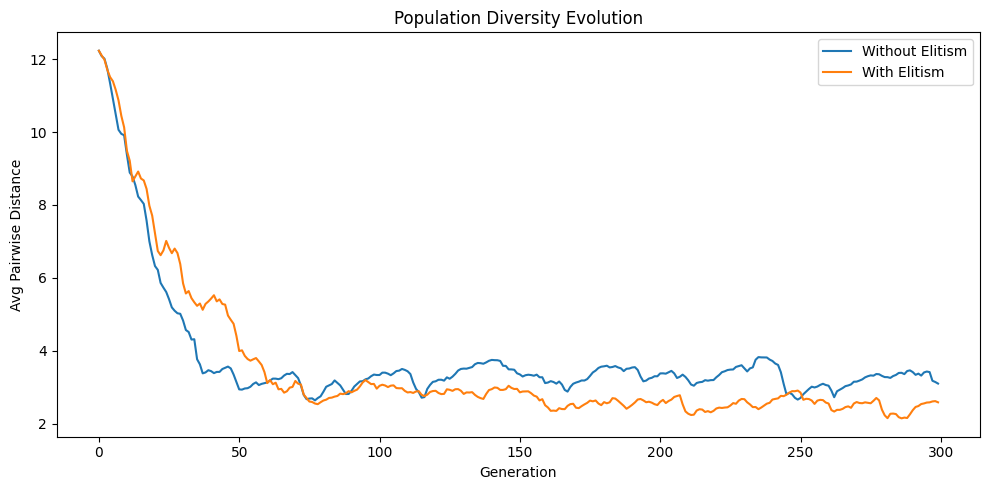

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(GA_NoElite[3], label='Without Elitism')
plt.plot(GA_Elite[3], label='With Elitism')
plt.xlabel('Generation')
plt.ylabel('Avg Pairwise Distance')
plt.title('Population Diversity Evolution')
plt.legend()
plt.tight_layout()
plt.savefig('output/diversity_evolution.png', bbox_inches='tight')
plt.show()

#### Comparison between Fitness Evolution and Diversity Evolution

Let's put both graphs side by side and let's take some conclusions

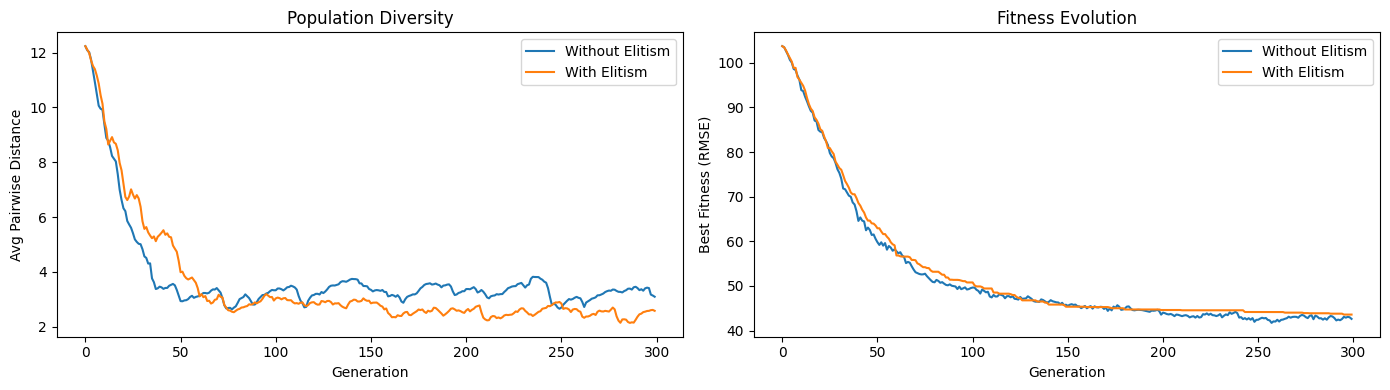

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(GA_NoElite[3], label='Without Elitism')
axes[0].plot(GA_Elite[3], label='With Elitism')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Avg Pairwise Distance')
axes[0].set_title('Population Diversity')
axes[0].legend()

axes[1].plot(GA_NoElite[1], label='Without Elitism')
axes[1].plot(GA_Elite[1], label='With Elitism')
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Best Fitness (RMSE)')
axes[1].set_title('Fitness Evolution')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/fitness_and_diversity.png', bbox_inches='tight')
plt.show()

As we can see the diversity falls a lot in the early generations, both with elitism and without elitism. And we also see that the fitness starts to reach a plateau in the early generations.</br>
This tell us that if we want to increase the number of generations, it might be a good ideia to apply **Fitness Sharing**.

### Final Result

Let's visualize and compare the original image and the best solution

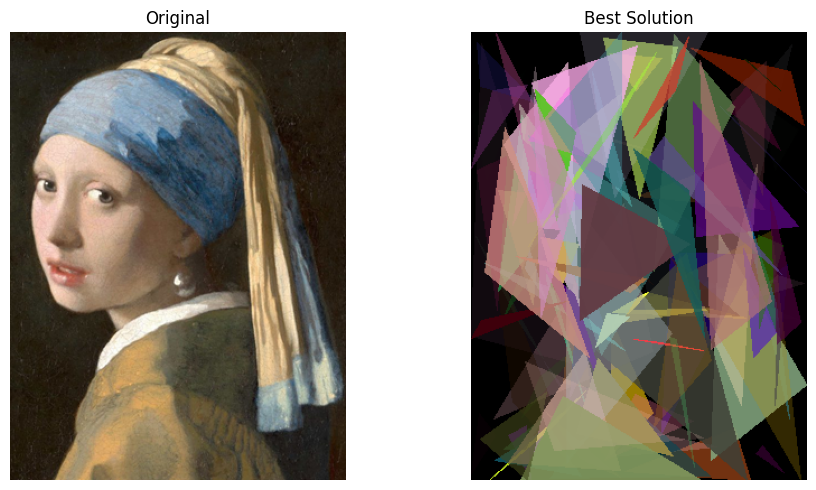

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(GA_Elite[0].render())
axes[1].set_title('Best Solution')
axes[1].axis('off')

plt.tight_layout()
fig.savefig('output/original_vs_best.png', bbox_inches='tight')
plt.show()

Let's see the evolution through the generations

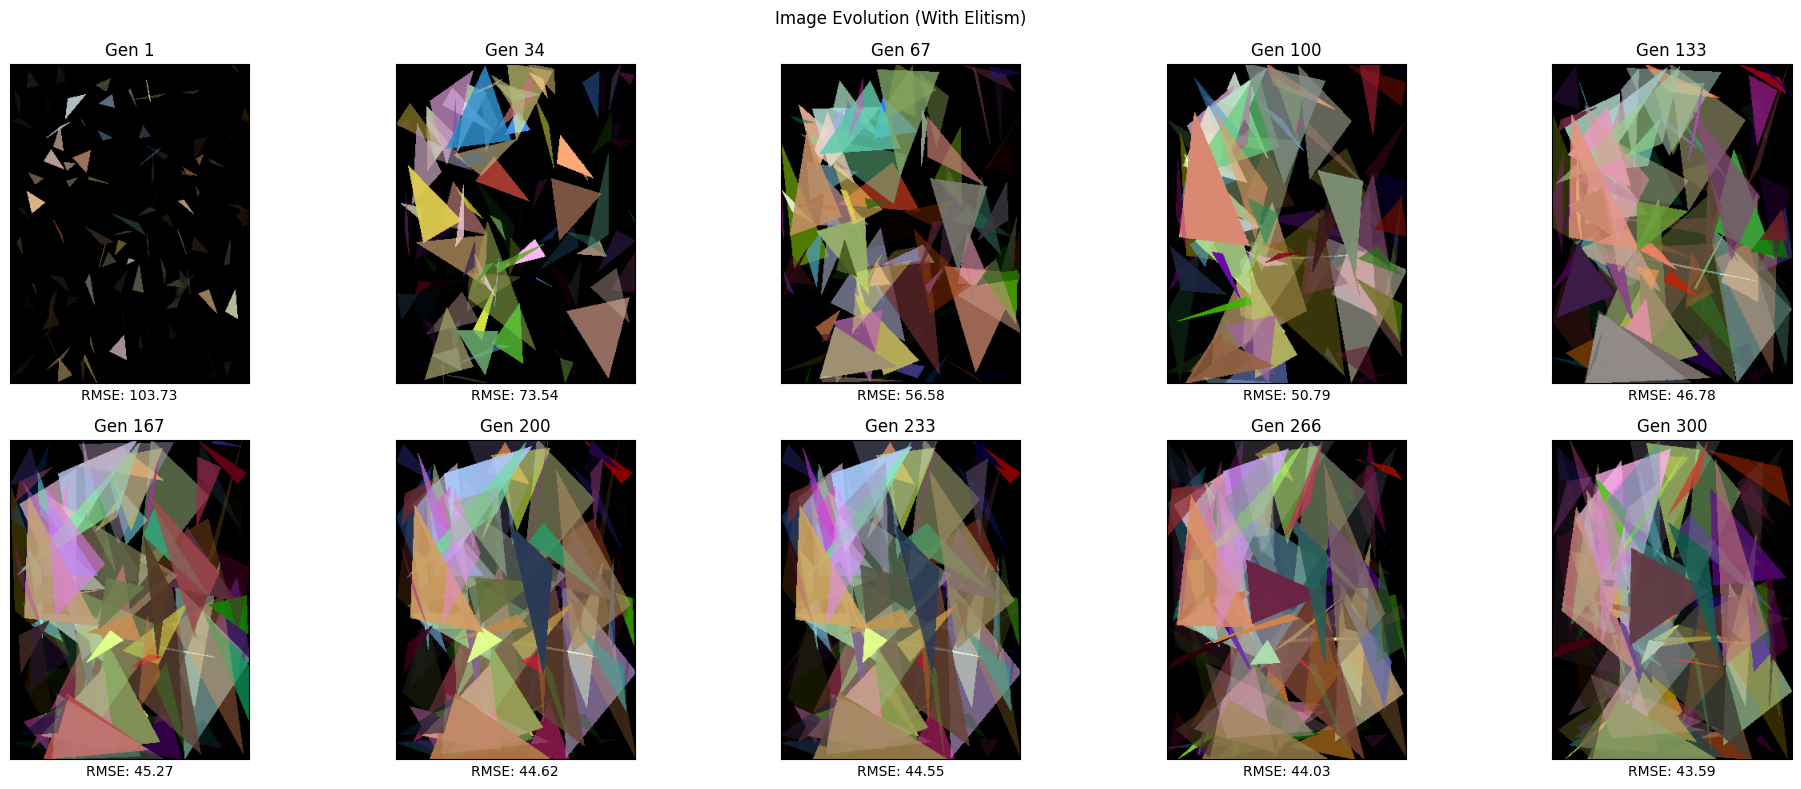

In [48]:
n_snapshots = 10
individuals = GA_Elite[2]  # best_individuals_over_gens
indices = np.linspace(0, len(individuals) - 1, n_snapshots, dtype=int)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for ax, idx in zip(axes, indices):
    ax.imshow(individuals[idx].render())
    ax.set_title(f'Gen {idx + 1}')
    ax.set_xlabel(f'RMSE: {GA_Elite[1][idx]:.2f}')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Image Evolution (With Elitism)')
plt.tight_layout()
fig.savefig('output/image_evolution.png', bbox_inches='tight')
plt.show()

## 4. Ablation Study - Selection, Crossover, Mutation

### Selection - Tournament vs Rank Selection

Now we will run the GA with rank selection and with tournament selection, and let's compare the results for both.</br>
Since we saw that with elitism we had better results, we're going to keep it exactly the same, and only switch the selection method.

In [49]:
# Create the initial population of solutions
def create_population(size=100):
    population = []
    for _ in range(size):
        population.append(TriangleSolution(
            target_array=original_image_array,
            img_width=original_image.width,
            img_height=original_image.height,
            n_triangles=100,
        ))
    return population

# Run tournament selection with elitism
random.seed(1)
GA_Tournament = genetic_algorithm(
    initial_population=create_population(),
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=one_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False
)


# Run rank selection with elitism
random.seed(1)
GA_Rank = genetic_algorithm(
    initial_population=create_population(),
    max_generations=300,
    selection_algorithm=rank_selection,
    xo_method=one_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False
)

print(f'---------- Final Results ----------')
print(f'Best solution with tournament selection has fitness: {GA_Tournament[0].fitness()}')
print(f'Best solution with rank selection has fitness: {GA_Rank[0].fitness()}')

----- Generation 1/300, duration: 0.00 -----
----- Generation 2/300, duration: 1.39 -----
----- Generation 3/300, duration: 2.07 -----
----- Generation 4/300, duration: 2.76 -----
----- Generation 5/300, duration: 3.44 -----
----- Generation 6/300, duration: 4.13 -----
----- Generation 7/300, duration: 4.81 -----
----- Generation 8/300, duration: 5.50 -----
----- Generation 9/300, duration: 6.19 -----
----- Generation 10/300, duration: 6.87 -----
----- Generation 11/300, duration: 7.56 -----
----- Generation 12/300, duration: 8.25 -----
----- Generation 13/300, duration: 8.93 -----
----- Generation 14/300, duration: 9.62 -----
----- Generation 15/300, duration: 10.31 -----
----- Generation 16/300, duration: 11.00 -----
----- Generation 17/300, duration: 11.69 -----
----- Generation 18/300, duration: 12.38 -----
----- Generation 19/300, duration: 13.07 -----
----- Generation 20/300, duration: 13.75 -----
----- Generation 21/300, duration: 14.44 -----
----- Generation 22/300, duration: 1

Now let's visualize the **Fitness Evolution** for both algorithms

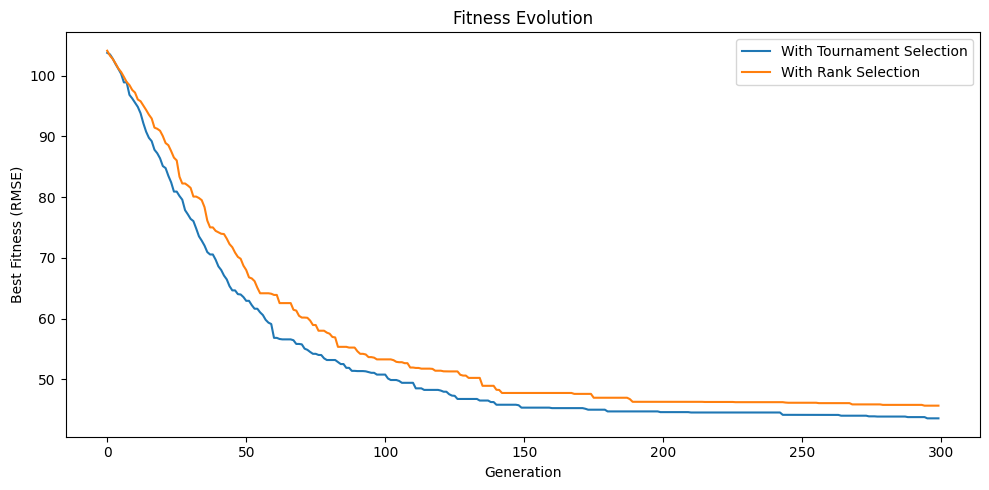

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(GA_Tournament[1], label='With Tournament Selection')
plt.plot(GA_Rank[1], label='With Rank Selection')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (RMSE)')
plt.title('Fitness Evolution')
plt.legend()
plt.tight_layout()
plt.savefig('output/tournament_vs_rank.png', bbox_inches='tight')
plt.show()

### Crossover - One-Point vs Two-Point

Now we will run the GA with one-point crossover and two-point crossover, and let's compare the results for both.</br>
Since we saw that with elitism we had better results, we're going to keep it exactly the same, and only switch the crossover method.

In [51]:
# Create the initial population of solutions
def create_population(size=100):
    population = []
    for _ in range(size):
        population.append(TriangleSolution(
            target_array=original_image_array,
            img_width=original_image.width,
            img_height=original_image.height,
            n_triangles=100,
        ))
    return population

# Run GA with one-point crossover
random.seed(1)
GA_One_Point = genetic_algorithm(
    initial_population=create_population(),
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=one_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False
)


# Run GA with two-point crossover
random.seed(1)
GA_Two_Point = genetic_algorithm(
    initial_population=create_population(),
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False
)

print(f'---------- Final Results ----------')
print(f'Best solution with one-point crossover has fitness: {GA_One_Point[0].fitness()}')
print(f'Best solution with two-point crossover has fitness: {GA_Two_Point[0].fitness()}')

----- Generation 1/300, duration: 0.00 -----
----- Generation 2/300, duration: 1.39 -----
----- Generation 3/300, duration: 2.08 -----
----- Generation 4/300, duration: 2.77 -----
----- Generation 5/300, duration: 3.45 -----
----- Generation 6/300, duration: 4.13 -----
----- Generation 7/300, duration: 4.82 -----
----- Generation 8/300, duration: 5.51 -----
----- Generation 9/300, duration: 6.19 -----
----- Generation 10/300, duration: 6.88 -----
----- Generation 11/300, duration: 7.57 -----
----- Generation 12/300, duration: 8.25 -----
----- Generation 13/300, duration: 8.94 -----
----- Generation 14/300, duration: 9.63 -----
----- Generation 15/300, duration: 10.32 -----
----- Generation 16/300, duration: 11.01 -----
----- Generation 17/300, duration: 11.69 -----
----- Generation 18/300, duration: 12.38 -----
----- Generation 19/300, duration: 13.07 -----
----- Generation 20/300, duration: 13.76 -----
----- Generation 21/300, duration: 14.45 -----
----- Generation 22/300, duration: 1

Now let's visualize the **Fitness Evolution** for both algorithms

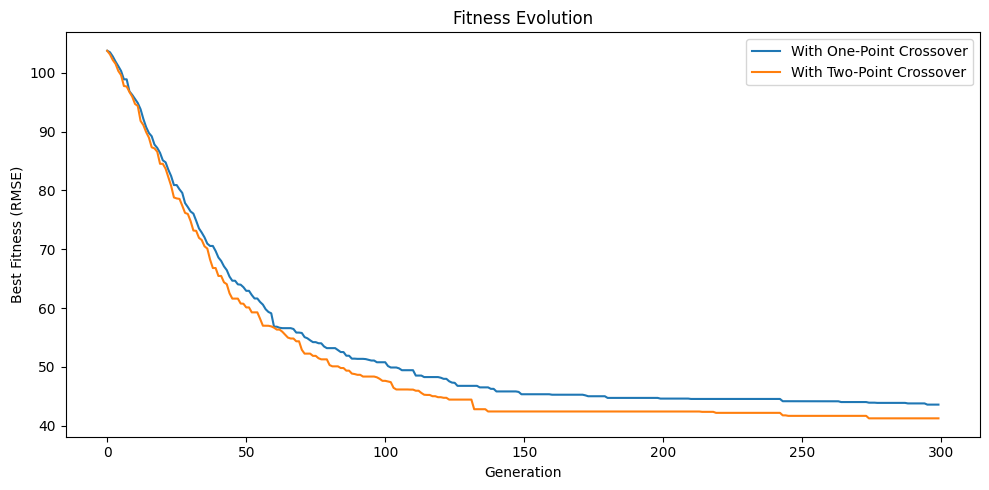

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(GA_One_Point[1], label='With One-Point Crossover')
plt.plot(GA_Two_Point[1], label='With Two-Point Crossover')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (RMSE)')
plt.title('Fitness Evolution')
plt.legend()
plt.tight_layout()
plt.savefig('output/one_point_vs_two_point.png', bbox_inches='tight')
plt.show()

### Mutation - Gaussian vs Uniform

Now we will run the GA with Gaussian mutation and Uniform Mutation, and let's compare the results for both.</br>
Since we saw that with elitism we had better results, we're going to keep it exactly the same, and only switch the mutation method.

In [53]:
# Create the initial population of solutions
def create_population(size=100):
    population = []
    for _ in range(size):
        population.append(TriangleSolution(
            target_array=original_image_array,
            img_width=original_image.width,
            img_height=original_image.height,
            n_triangles=100,
        ))
    return population

# Run GA with Gaussian mutation
random.seed(1)
GA_Gaussian = genetic_algorithm(
    initial_population=create_population(),
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=one_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False
)


# Run GA with Uniform mutation
random.seed(1)
GA_Uniform = genetic_algorithm(
    initial_population=create_population(),
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=one_point_crossover,
    mut_method=uniform_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False
)

print(f'---------- Final Results ----------')
print(f'Best solution with Gaussian mutation has fitness: {GA_Gaussian[0].fitness()}')
print(f'Best solution with Uniform mutation has fitness: {GA_Uniform[0].fitness()}')

----- Generation 1/300, duration: 0.00 -----
----- Generation 2/300, duration: 1.39 -----
----- Generation 3/300, duration: 2.08 -----
----- Generation 4/300, duration: 2.76 -----
----- Generation 5/300, duration: 3.45 -----
----- Generation 6/300, duration: 4.14 -----
----- Generation 7/300, duration: 4.83 -----
----- Generation 8/300, duration: 5.51 -----
----- Generation 9/300, duration: 6.20 -----
----- Generation 10/300, duration: 6.89 -----
----- Generation 11/300, duration: 7.57 -----
----- Generation 12/300, duration: 8.26 -----
----- Generation 13/300, duration: 8.95 -----
----- Generation 14/300, duration: 9.64 -----
----- Generation 15/300, duration: 10.33 -----
----- Generation 16/300, duration: 11.02 -----
----- Generation 17/300, duration: 11.71 -----
----- Generation 18/300, duration: 12.40 -----
----- Generation 19/300, duration: 13.09 -----
----- Generation 20/300, duration: 13.78 -----
----- Generation 21/300, duration: 14.47 -----
----- Generation 22/300, duration: 1

Now let's visualize the **Fitness Evolution** for both algorithms

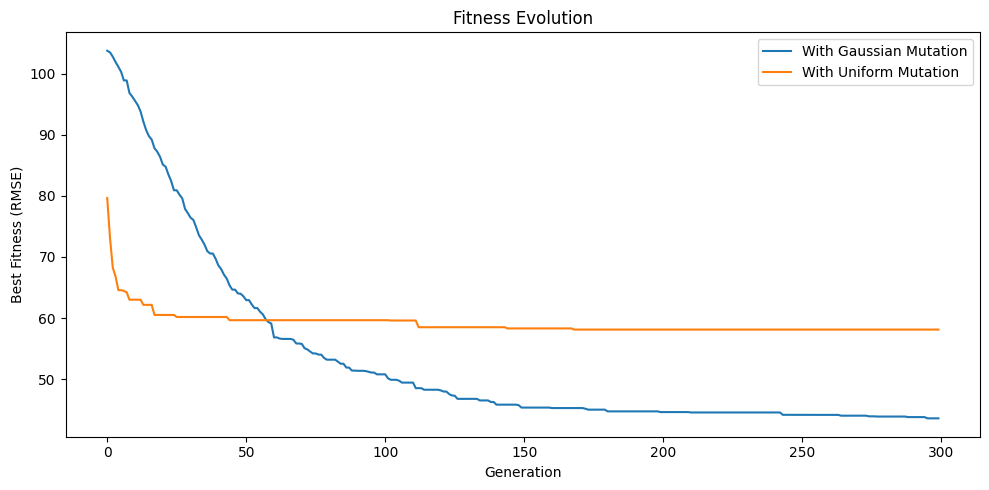

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(GA_Gaussian[1], label='With Gaussian Mutation')
plt.plot(GA_Uniform[1], label='With Uniform Mutation')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (RMSE)')
plt.title('Fitness Evolution')
plt.legend()
plt.tight_layout()
plt.savefig('output/gaussian_vs_uniform.png', bbox_inches='tight')
plt.show()

### Conclusion

From each comparison we can say that with a population size of 100 and with 300 generations the following methods performed better:</br>
</br>
**Selection Method**: Tournament Selection performed better.</br>
**Crossover Method**: Two-Point Crossover performed better.</br>
**Mutation Method**: Gaussian Mutation performed better.

## 5. Final GA Algorithm

Now we're going to select the best methods from the ablation study, we're going to increase the maximum number of generations and we're also going to apply Fitness Sharing to see what's the final result we can get

First let's test with and without elitism

In [55]:
random.seed(1)
GA_Final = genetic_algorithm(
    initial_population=create_population(size=100),
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=True,
    sigma_share=3.0,
    verbose=False
)

random.seed(1)
GA_Final_No_Elite = genetic_algorithm(
    initial_population=create_population(size=100),
    max_generations=300,
    selection_algorithm=tournament_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=False,
    fitness_sharing=True,
    sigma_share=3.0,
    verbose=False
)

print(f'---------- Final Results ----------')
print(f'Best solution with elitism has fitness: {GA_Final[0].fitness()}')
print(f'Best solution without elitism has fitness: {GA_Final_No_Elite[0].fitness()}')


----- Generation 1/300, duration: 0.00 -----
----- Generation 2/300, duration: 1.39 -----
----- Generation 3/300, duration: 2.08 -----
----- Generation 4/300, duration: 2.77 -----
----- Generation 5/300, duration: 3.46 -----
----- Generation 6/300, duration: 4.15 -----
----- Generation 7/300, duration: 4.84 -----
----- Generation 8/300, duration: 5.53 -----
----- Generation 9/300, duration: 6.22 -----
----- Generation 10/300, duration: 6.91 -----
----- Generation 11/300, duration: 7.60 -----
----- Generation 12/300, duration: 8.29 -----
----- Generation 13/300, duration: 8.98 -----
----- Generation 14/300, duration: 9.67 -----
----- Generation 15/300, duration: 10.37 -----
----- Generation 16/300, duration: 11.06 -----
----- Generation 17/300, duration: 11.75 -----
----- Generation 18/300, duration: 12.44 -----
----- Generation 19/300, duration: 13.13 -----
----- Generation 20/300, duration: 13.83 -----
----- Generation 21/300, duration: 14.52 -----
----- Generation 22/300, duration: 1

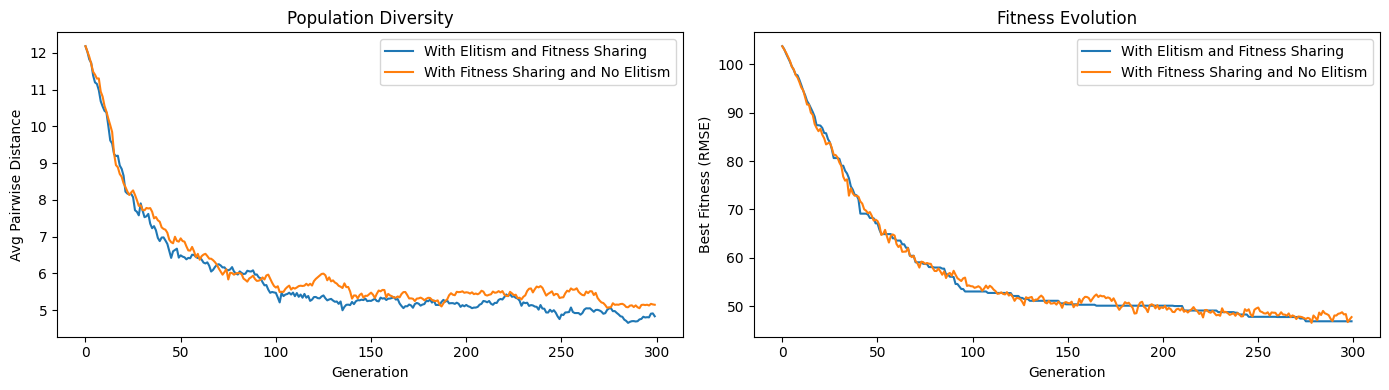

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(GA_Final[3], label = 'With Elitism and Fitness Sharing')
axes[0].plot(GA_Final_No_Elite[3], label = 'With Fitness Sharing and No Elitism')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Avg Pairwise Distance')
axes[0].set_title('Population Diversity')
axes[0].legend()

axes[1].plot(GA_Final[1], label='With Elitism and Fitness Sharing')
axes[1].plot(GA_Final_No_Elite[1], label='With Fitness Sharing and No Elitism')
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Best Fitness (RMSE)')
axes[1].set_title('Fitness Evolution')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/fitness_and_diversity_with_fitness_sharing.png', bbox_inches='tight')
plt.show()

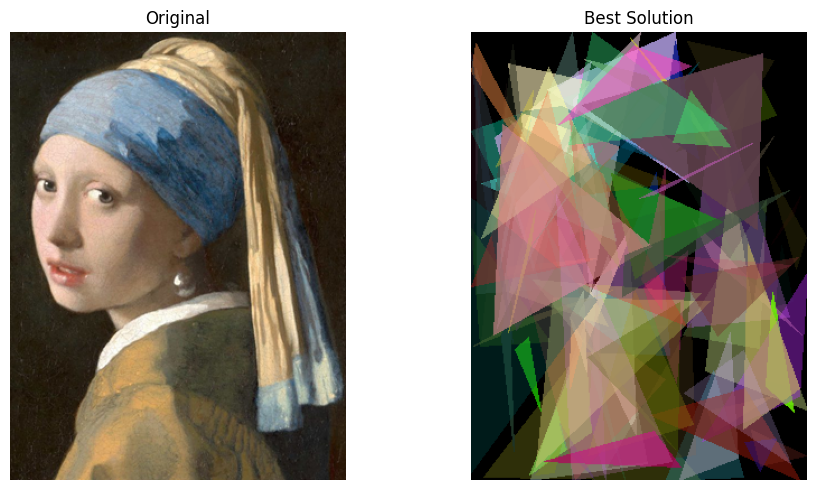

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(GA_Final[0].render())
axes[1].set_title('Best Solution')
axes[1].axis('off')

plt.tight_layout()
fig.savefig('output/original_vs_best_2.0.png', bbox_inches='tight')
plt.show()

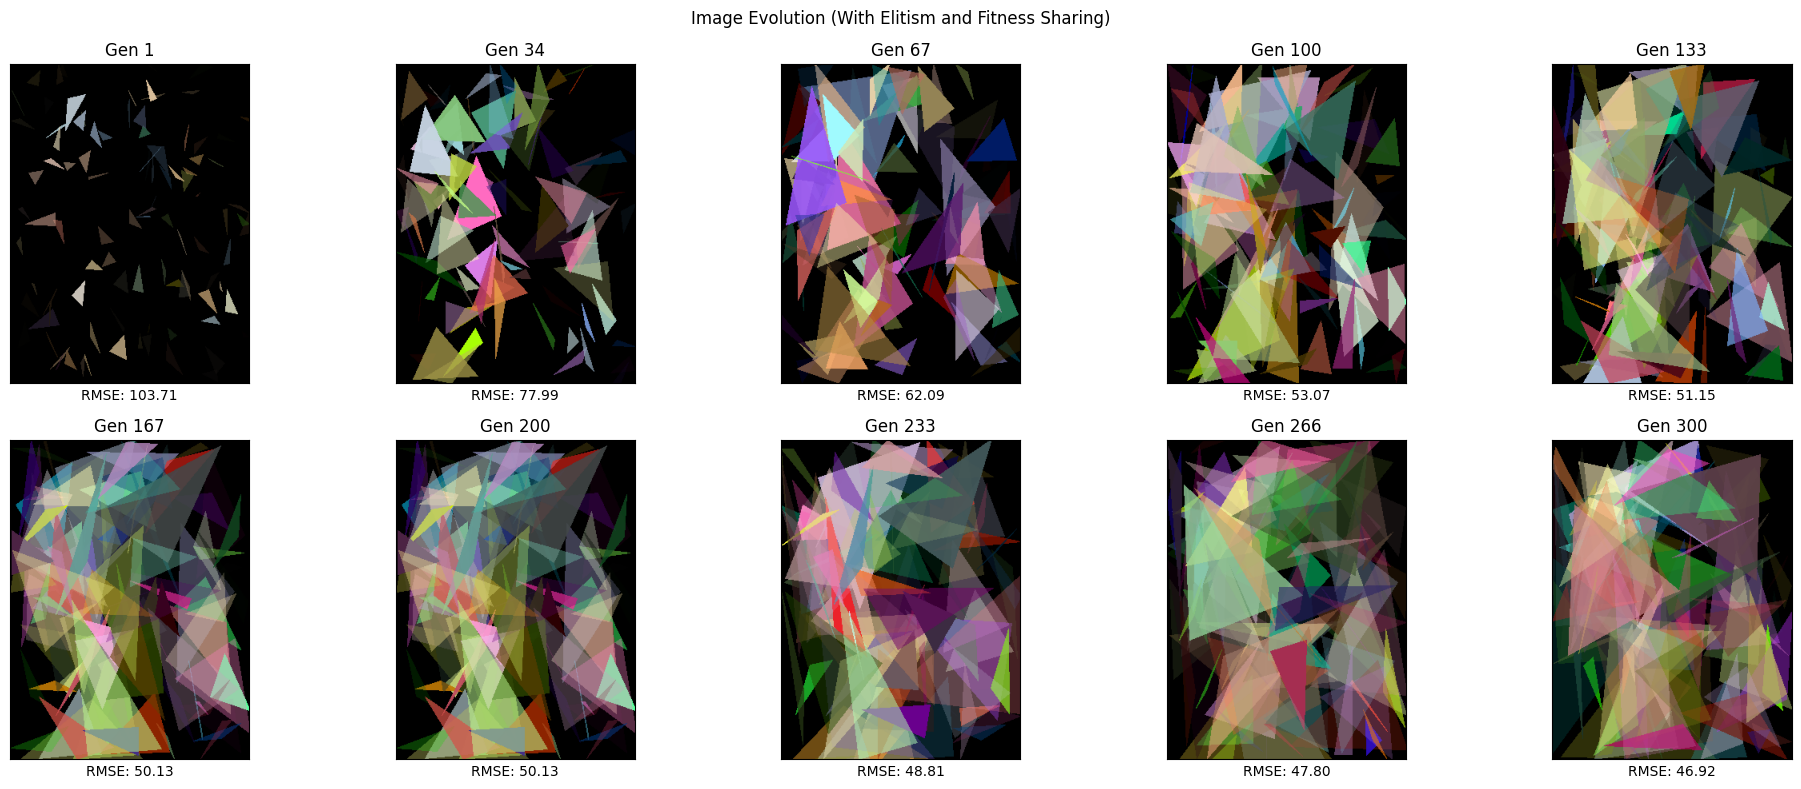

In [58]:
n_snapshots = 10
individuals = GA_Final[2]  # best_individuals_over_gens
indices = np.linspace(0, len(individuals) - 1, n_snapshots, dtype=int)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for ax, idx in zip(axes, indices):
    ax.imshow(individuals[idx].render())
    ax.set_title(f'Gen {idx + 1}')
    ax.set_xlabel(f'RMSE: {GA_Final[1][idx]:.2f}')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Image Evolution (With Elitism and Fitness Sharing)')
plt.tight_layout()
fig.savefig('output/image_evolution_with_fitness_sharing.png', bbox_inches='tight')
plt.show()

In [59]:
random.seed(1)
GA = genetic_algorithm(
    initial_population=create_population(size=100),
    max_generations=500,
    selection_algorithm=tournament_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=True,
    fitness_sharing=True,
    sigma_share=3.0,
    verbose=False
)

print(f'---------- Final Result ----------')
print(f'Best solution with elitism has fitness: {GA[0].fitness()}')

----- Generation 1/500, duration: 0.00 -----
----- Generation 2/500, duration: 1.33 -----
----- Generation 3/500, duration: 2.02 -----
----- Generation 4/500, duration: 2.68 -----
----- Generation 5/500, duration: 3.35 -----
----- Generation 6/500, duration: 4.01 -----
----- Generation 7/500, duration: 4.68 -----
----- Generation 8/500, duration: 5.35 -----
----- Generation 9/500, duration: 6.06 -----
----- Generation 10/500, duration: 6.74 -----
----- Generation 11/500, duration: 7.42 -----
----- Generation 12/500, duration: 8.11 -----
----- Generation 13/500, duration: 8.79 -----
----- Generation 14/500, duration: 9.48 -----
----- Generation 15/500, duration: 10.17 -----
----- Generation 16/500, duration: 10.89 -----
----- Generation 17/500, duration: 11.58 -----
----- Generation 18/500, duration: 12.26 -----
----- Generation 19/500, duration: 12.94 -----
----- Generation 20/500, duration: 13.62 -----
----- Generation 21/500, duration: 14.31 -----
----- Generation 22/500, duration: 1

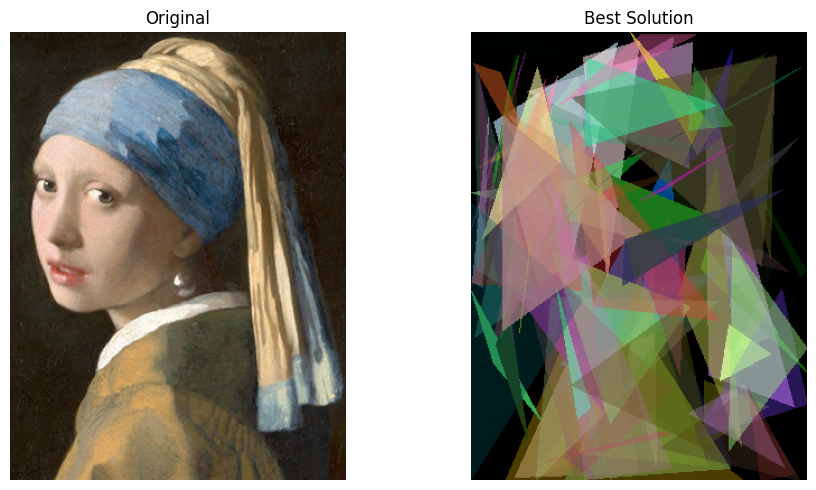

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(GA[0].render())
axes[1].set_title('Best Solution')
axes[1].axis('off')

plt.tight_layout()
fig.savefig('output/GA.png', bbox_inches='tight')
plt.show()

In [62]:
random.seed(1)
GA_NoElite_FS = genetic_algorithm(
    initial_population=create_population(size=100),
    max_generations=500,
    selection_algorithm=tournament_selection,
    xo_method=two_point_crossover,
    mut_method=gaussian_mutation,
    minimization=True,
    xo_prob=0.9,
    mut_prob=0.1,
    elitism=False,
    fitness_sharing=False,
    sigma_share=3.0,
    verbose=False
)

print(f'---------- Final Result ----------')
print(f'Best solution without elitism and fitness sharing has fitness: {GA_NoElite_FS[0].fitness()}')

----- Generation 1/500, duration: 0.00 -----
----- Generation 2/500, duration: 1.29 -----
----- Generation 3/500, duration: 1.94 -----
----- Generation 4/500, duration: 2.59 -----
----- Generation 5/500, duration: 3.25 -----
----- Generation 6/500, duration: 3.90 -----
----- Generation 7/500, duration: 4.55 -----
----- Generation 8/500, duration: 5.21 -----
----- Generation 9/500, duration: 5.86 -----
----- Generation 10/500, duration: 6.56 -----
----- Generation 11/500, duration: 7.30 -----
----- Generation 12/500, duration: 7.96 -----
----- Generation 13/500, duration: 8.64 -----
----- Generation 14/500, duration: 9.32 -----
----- Generation 15/500, duration: 9.99 -----
----- Generation 16/500, duration: 10.66 -----
----- Generation 17/500, duration: 11.34 -----
----- Generation 18/500, duration: 12.01 -----
----- Generation 19/500, duration: 12.69 -----
----- Generation 20/500, duration: 13.36 -----
----- Generation 21/500, duration: 14.04 -----
----- Generation 22/500, duration: 14

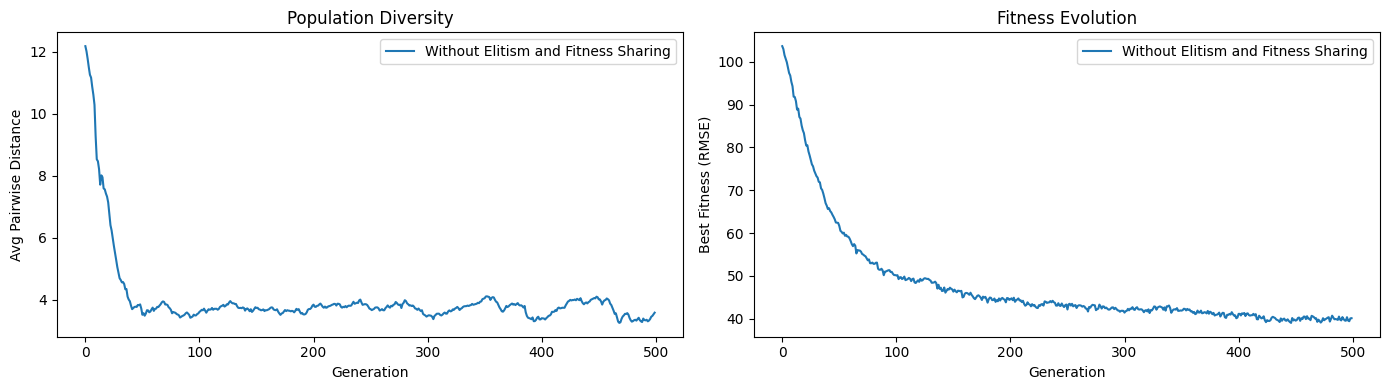

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(GA_NoElite_FS[3], label = 'Without Elitism and Fitness Sharing')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Avg Pairwise Distance')
axes[0].set_title('Population Diversity')
axes[0].legend()

axes[1].plot(GA_NoElite_FS[1], label='Without Elitism and Fitness Sharing')
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Best Fitness (RMSE)')
axes[1].set_title('Fitness Evolution')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/fitness_and_diversity_with_fitness_sharing.png', bbox_inches='tight')
plt.show()